# Importing libraries

In [159]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [160]:
pd.set_option('display.max_columns', None)

In [161]:
df=pd.read_csv("data/data.csv")
df

,Gene_Symbol,rsID,Chromosome,Position,Ref_Allele,Alt_Allele,Variant_Type,Variant_Type_Label,Non_Coding_Region,Non_Coding_Region_Label,H3K4me3,H3K27ac,Top_TF_Binding,TF_Count,ClinVar_Significance,ClinVar_Significance_Label,GTEx_eQTL,Known_Regulatory_Effect,Training_Split,H3K4me3_PeakCount,H3K4me3_CellLines,H3K27ac_PeakCount,H3K27ac_CellLines,H3K4me3_PeakScore,H3K27ac_PeakScore,Sequence_Ref,Sequence_Alt,PhyloP_Score,Sequence_Status,TF_MNT_disrupted,TF_MNT_created,TF_CTCF_disrupted,TF_CTCF_created,TF_MAX_disrupted,TF_MAX_created,TF_PKNOX1_disrupted,TF_PKNOX1_created,TF_GABPA_disrupted,TF_GABPA_created,TF_ELF1_disrupted,TF_ELF1_created,TF_CREB1_disrupted,TF_CREB1_created,TF_E2F1_disrupted,TF_E2F1_created,TF_TOE1_disrupted,TF_TOE1_created,TF_ELK1_disrupted,TF_ELK1_created,TF_ZNF444_disrupted,TF_ZNF444_created,TF_OVOL1_disrupted,TF_OVOL1_created,TF_ZBTB40_disrupted,TF_ZBTB40_created,TF_NFIB_disrupted,TF_NFIB_created,TF_MAZ_disrupted,TF_MAZ_created,TF_ATF7_disrupted,TF_ATF7_created,TF_CLOCK_disrupted,TF_CLOCK_created,TF_ZFX_disrupted,TF_ZFX_created,TF_FOS_disrupted,TF_FOS_created,TF_FOXA1_disrupted,TF_FOXA1_created,TF_CEBPB_disrupted,TF_CEBPB_created,TF_MBD2_disrupted,TF_MBD2_created,TF_SPDEF_disrupted,TF_SPDEF_created,TF_SREBF1_disrupted,TF_SREBF1_created,TF_JUND_disrupted,TF_JUND_created,TF_RFX1_disrupted,TF_RFX1_created,TF_SRF_disrupted,TF_SRF_created,TF_CEBPG_disrupted,TF_CEBPG_created,TF_RFX5_disrupted,TF_RFX5_created,TF_MSX2_disrupted,TF_MSX2_created,TF_ZNF507_disrupted,TF_ZNF507_created,TF_KLF9_disrupted,TF_KLF9_created,TF_MYC_disrupted,TF_MYC_created,TF_ZBTB11_disrupted,TF_ZBTB11_created,TF_ESR1_disrupted,TF_ESR1_created,TF_GATA3_disrupted,TF_GATA3_created,TF_NR2F2_disrupted,TF_NR2F2_created,TF_TCF7L2_disrupted,TF_TCF7L2_created,TF_E4F1_disrupted,TF_E4F1_created,TF_E2F8_disrupted,TF_E2F8_created,TF_EGR1_disrupted,TF_EGR1_created,TF_E2F4_disrupted,TF_E2F4_created,TF_NRF1_disrupted,TF_NRF1_created,TF_ZNF574_disrupted,TF_ZNF574_created,TF_FOXM1_disrupted,TF_FOXM1_created,TF_FOSL2_disrupted,TF_FOSL2_created,TF_Count_Disrupted,TF_Count_Created,Max_Disruption_Score,Most_Disrupted_TF,Most_Created_TF,Motif_Score_Reliable
0,BRCA1,rs8176320,Chr17,43044346,C,G,0,single nucleotide variant,0,3_prime_UTR,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,11,1,likely-benign,0,0.0,Train,0,NaN,0,NaN,0.0,0.0000,GGAAGTGTTTGCTACCAAGTTTATTTGCAGTGTTAACAGCACAACA...,GGAAGTGTTTGCTACCAAGTTTATTTGCAGTGTTAACAGCACAACA...,0.2757,ok,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,1
1,BRCA1,rs12516,Chr17,43044391,G,A,0,single nucleotide variant,0,3_prime_UTR,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,11,0,benign,0,0.0,Train,0,NaN,0,NaN,0.0,0.0000,ATTTACAAAACGTATTTTGTACAATCAAGTCTTCACTGCCCTTGCA...,ATTTACAAAACGTATTTTGTACAATCAAGTCTTCACTGCCCTTGCA...,0.9063,ok,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,1
2,BRCA1,rs548275991,Chr17,43044392,G,A,0,single nucleotide variant,0,3_prime_UTR,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,11,1,likely-benign,0,0.0,Train,0,NaN,0,NaN,0.0,0.0000,TTTACAAAACGTATTTTGTACAATCAAGTCTTCACTGCCCTTGCAC...,TTTACAAAACGTATTTTGTACAATCAAGTCTTCACTGCCCTTGCAC...,0.5280,ok,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,1
3,BRCA1,rs8176319,Chr17,43044897,G,A,0,single nucleotide variant,0,3_prime_UTR,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,11,1,likely-benign,0,0.0,Test,0,NaN,0,NaN,0.0,0.0000,AGGCTGGAGTGCCGTGGTATGATCTTGGCTCACTGCAACCTCCACC...,AGGCTGGAGTGCCGTGGTATGATCTTGGCTCACTGCAACCTCCACC...,-0.1027,ok,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [162]:
df['ClinVar_Significance_Label'].value_counts()

ClinVar_Significance_Label
likely-benign                                   1079
uncertain-significance                           627
benign                                           314
conflicting-interpretations-of-pathogenicity     148
pathogenic                                       106
likely-pathogenic                                 73
not-provided                                      30
benign-likely-benign                              13
pathogenic-likely-pathogenic                      11
Name: count, dtype: int64

In [163]:
df['Known_Regulatory_Effect'].value_counts()

Known_Regulatory_Effect
0.0    1405
1.0     192
Name: count, dtype: int64

In [164]:
print(df.value_counts(['Known_Regulatory_Effect', 'ClinVar_Significance_Label']))

Known_Regulatory_Effect  ClinVar_Significance_Label                  
0.0                      likely-benign                                   1079
                         benign                                           313
1.0                      pathogenic                                       106
                         likely-pathogenic                                 73
0.0                      benign-likely-benign                              13
1.0                      pathogenic-likely-pathogenic                      11
                         benign                                             1
                         conflicting-interpretations-of-pathogenicity       1
Name: count, dtype: int64


# Data Exploration, Preprocessing


Note:
Variant_Type: 0=SNV, 1=indel, 2=deletion, 3=insertion, 4=other

Non_Coding_Region: 0=3'UTR, 1=5'UTR, 2=intronic, 3=splice region, 4=upstream, 5=downstream, 6=intergenic, 7=nc transcript, 8=regulatory, 9=other

ClinVar_Significance: -1=missing, 0=benign, 1=likely-benign, 2=uncertain, 3=likely-pathogenic, 4=pathogenic
* using this as label, with just "benign", "likely-benign", "pathogenic","likely-pathogenic"

* Drop unlabelled/uncertain data
* Remove columns with single-valued or null-valued values:

In [165]:

data = df
data["ClinVar_Significance_Label"].value_counts()
for col in data.columns: # drop homogeneous columns
    if(len(data[col].value_counts())==1):
        data.drop(col, axis=1, inplace=True)
data.drop("H3K27ac_CellLines",axis=1,inplace=True)
data.drop("Known_Regulatory_Effect",axis=1,inplace=True)

see dataframe column info, validate that the remaining data is what we want


In [166]:
data.info()
for col in data.columns:
    print(f"--------- Value counts for {col}")
    print(data[col].value_counts())
    print(len(data[col].value_counts()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2401 entries, 0 to 2400
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gene_Symbol                 2401 non-null   object 
 1   rsID                        2401 non-null   object 
 2   Chromosome                  2401 non-null   object 
 3   Position                    2401 non-null   int64  
 4   Ref_Allele                  1996 non-null   object 
 5   Alt_Allele                  1996 non-null   object 
 6   Variant_Type                2401 non-null   int64  
 7   Variant_Type_Label          2386 non-null   object 
 8   Non_Coding_Region           2401 non-null   int64  
 9   Non_Coding_Region_Label     2401 non-null   object 
 10  H3K4me3                     2401 non-null   int64  
 11  H3K27ac                     2401 non-null   int64  
 12  Top_TF_Binding              2401 non-null   object 
 13  ClinVar_Significance        2401 

In [167]:
display(data)

,Gene_Symbol,rsID,Chromosome,Position,Ref_Allele,Alt_Allele,Variant_Type,Variant_Type_Label,Non_Coding_Region,Non_Coding_Region_Label,H3K4me3,H3K27ac,Top_TF_Binding,ClinVar_Significance,ClinVar_Significance_Label,GTEx_eQTL,Training_Split,H3K4me3_PeakCount,H3K4me3_PeakScore,H3K27ac_PeakScore,Sequence_Ref,Sequence_Alt,PhyloP_Score,Sequence_Status,TF_MNT_disrupted,TF_MNT_created,TF_MAX_disrupted,TF_MAX_created,TF_ELF1_disrupted,TF_CREB1_disrupted,TF_CREB1_created,TF_TOE1_created,TF_ELK1_disrupted,TF_ELK1_created,TF_OVOL1_created,TF_CLOCK_disrupted,TF_ZFX_disrupted,TF_ZFX_created,TF_FOS_disrupted,TF_FOS_created,TF_FOXA1_created,TF_MBD2_created,TF_JUND_disrupted,TF_CEBPG_created,TF_MSX2_disrupted,TF_MSX2_created,TF_MYC_disrupted,TF_GATA3_disrupted,TF_GATA3_created,TF_NR2F2_disrupted,TF_NR2F2_created,TF_E4F1_disrupted,TF_E4F1_created,TF_E2F8_disrupted,TF_E2F8_created,TF_FOXM1_disrupted,TF_FOXM1_created,TF_FOSL2_disrupted,TF_FOSL2_created,TF_Count_Disrupted,TF_Count_Created,Max_Disruption_Score,Most_Disrupted_TF,Most_Created_TF,Motif_Score_Reliable
0,BRCA1,rs8176320,Chr17,43044346,C,G,0,single nucleotide variant,0,3_prime_UTR,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,1,likely-benign,0,Train,0,0.0,0.0000,GGAAGTGTTTGCTACCAAGTTTATTTGCAGTGTTAACAGCACAACA...,GGAAGTGTTTGCTACCAAGTTTATTTGCAGTGTTAACAGCACAACA...,0.2757,ok,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,1
1,BRCA1,rs12516,Chr17,43044391,G,A,0,single nucleotide variant,0,3_prime_UTR,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,0,benign,0,Train,0,0.0,0.0000,ATTTACAAAACGTATTTTGTACAATCAAGTCTTCACTGCCCTTGCA...,ATTTACAAAACGTATTTTGTACAATCAAGTCTTCACTGCCCTTGCA...,0.9063,ok,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,1
2,BRCA1,rs548275991,Chr17,43044392,G,A,0,single nucleotide variant,0,3_prime_UTR,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,1,likely-benign,0,Train,0,0.0,0.0000,TTTACAAAACGTATTTTGTACAATCAAGTCTTCACTGCCCTTGCAC...,TTTACAAAACGTATTTTGTACAATCAAGTCTTCACTGCCCTTGCAC...,0.5280,ok,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,1
3,BRCA1,rs8176319,Chr17,43044897,G,A,0,single nucleotide variant,0,3_prime_UTR,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,1,likely-benign,0,Test,0,0.0,0.0000,AGGCTGGAGTGCCGTGGTATGATCTTGGCTCACTGCAACCTCCACC...,AGGCTGGAGTGCCGTGGTATGATCTTGGCTCACTGCAACCTCCACC...,-0.1027,ok,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,1
4,BRCA1,rs8176318,Chr17,43045257,C,A,0,single nucleotide variant,0,3_prime_UTR,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,0,benign,1,Train,0,0.0,0.0000,CATAATCGATCCCAAGCACTCTCCTTCCATTGAAGGGTCTGACTCT...,CATAATCGATCCCAAGCACTCTCCTTCCATTGAAGGGTCTGACTCT...,0.8887,ok,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2396,CHEK2,rs1033667,Chr22,28734312,C,T,0,single nucleotide variant,2,intronic,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; TAF1,0,benign,0,Train,0,0.0,0.0000,TTGTTCATGCATGATGTTCAATTATTTGTTCAACGTGCCAAAAACC...,TTGTTCATGCATGATGTTCAATTATTTGTTCAACGTGCCAAAAACC...,-0.6244,ok,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,1
2397,CHEK2,rs3841692,Chr22,28734360,NaN,NaN,1,indel,2,intronic,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; TAF1,0,benign,0,Validation,0,0.0,0.0000,GACAACTCCAATCAGAACCTTCCACCTGGTAATACAACTTTCTGTA...,GACAACTCCAATCAGAACCTTCCACCTGGTAATACAACTTTCTGTA...,0.0212,no_refalt,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,0
2398,CHEK2,rs587780181,Chr22,28734462,NaN,NaN,1,indel,1,5_prime_UTR,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; TAF1,2,conflicting-interpretations-of-pathogenicity,0,unlabeled,0,0.0,0.0000,

Alternative: Label Benign samples as 0, Pathogenic as 1? compare models...?

In [168]:
def add_clinvar_target_label(x):
    if x == "benign" or x == "benign-likely-benign":
        return 0
    elif x == "likely-benign":
        return 1
    elif x == "likely-pathogenic":
        return 2
    elif x == "pathogenic" or x == "pathogenic-likely-pathogenic":
        return 3
    else:
        return np.nan


NOTE: skipping  'Sequence_Alt', 'Sequence_Ref' - change this if needed

In [169]:
non_categorical_data = ['Position', 'H3K4me3', 'H3K27ac','GTEx_eQTL', 'Training_Split',  'H3K4me3_PeakCount', 'H3K4me3_PeakScore', 'H3K27ac_PeakScore','PhyloP_Score', 'TF_MNT_disrupted', 'TF_MNT_created', 'TF_MAX_disrupted', 'TF_MAX_created', 'TF_ELF1_disrupted', 'TF_CREB1_disrupted', 'TF_CREB1_created', 'TF_TOE1_created', 'TF_ELK1_disrupted', 'TF_OVOL1_created', 'TF_ZFX_disrupted', 'TF_ZFX_created', 'TF_FOS_disrupted', 'TF_FOS_created', 'TF_FOXA1_created', 'TF_JUND_disrupted', 'TF_MSX2_created', 'TF_MYC_disrupted', 'TF_GATA3_disrupted', 'TF_GATA3_created', 'TF_NR2F2_disrupted', 'TF_NR2F2_created', 'TF_E4F1_disrupted', 'TF_E4F1_created', 'TF_E2F8_disrupted', 'TF_E2F8_created', 'TF_FOXM1_created', 'TF_FOSL2_disrupted', 'Max_Disruption_Score', 'Motif_Score_Reliable']

In [ ]:
encoded_columns=[]
nc_region_label = pd.get_dummies(data["Non_Coding_Region_Label"],prefix="nc_region",dtype=int)
encoded_columns.append(nc_region_label)

encode_gene_symbol = pd.get_dummies(data["Gene_Symbol"],prefix="gene_symbol", dtype=int)
encoded_columns.append(encode_gene_symbol)

encode_chromosome = pd.get_dummies(data["Chromosome"],dtype=int, prefix="chromosome")
encoded_columns.append(encode_chromosome)

encode_variant_type = pd.get_dummies(data["Variant_Type_Label"],dtype=int) # this ok?
encoded_columns.append(encode_variant_type)

enc_Top_TF_Bind = pd.get_dummies(data["Top_TF_Binding"],dtype=int, prefix='TF_binding')
encoded_columns.append(enc_Top_TF_Bind)

enc_seq_status = pd.get_dummies(data["Sequence_Status"],dtype=int, prefix="status")
encoded_columns.append(enc_seq_status)

enc_count_dis = pd.get_dummies(data["TF_Count_Disrupted"],dtype=int,prefix="TF_count_disrupt")
encoded_columns.append(enc_count_dis)

enc_tf_count_create = pd.get_dummies(data["TF_Count_Created"],dtype=int,prefix = "TF_Count_Created")
encoded_columns.append(enc_tf_count_create)

enc_tf_most_disrupt = pd.get_dummies(data["Most_Disrupted_TF"],dtype=int, prefix="disrupted_tf")
encoded_columns.append(enc_tf_most_disrupt)

enc_tf_most_create = pd.get_dummies(data["Most_Created_TF"],dtype=int, prefix="created_tf")
encoded_columns.append(enc_tf_most_create)



Put everything into dataframe model will use. Convert dataframe -> np array

In [171]:
labels_out =  ["uncertain-significance", "not-provided", "conflicting-interpretations-of-pathogenicity"]

In [ ]:
model_data = pd.DataFrame()
model_data = pd.concat(encoded_columns, axis=1)
model_data = pd.concat([model_data, data[non_categorical_data]], axis=1)
model_data["target_label"] = data["ClinVar_Significance_Label"]


unknown_model_data = model_data[
    model_data["target_label"].isin(labels_out)
].copy()
unknown_model_data.drop(["Training_Split", 'target_label'],axis=1,inplace=True)
model_data = model_data[
    ~model_data["target_label"].isin(labels_out)
]
model_data["target_label"] = model_data["target_label"].map(add_clinvar_target_label)

_before = len(model_data)
model_data = model_data.dropna(subset=["target_label"])
if len(model_data) < _before:
    print(f"Dropped {_before - len(model_data)} labeled rows with unmapped ClinVar labels (unexpected values).")


,nc_region_3_prime_UTR,nc_region_5_prime_UTR,nc_region_intronic,nc_region_nc_transcript,nc_region_splice_region,nc_region_upstream,ATM,BRCA1,BRCA2,CHEK2,PALB2,STK11,TP53,Chr11,Chr13,Chr16,Chr17,Chr19,Chr22,deletion,indel,insertion,single nucleotide variant,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; TAF1,CTCF; POLR2A; POLR2AphosphoS5; H2AFZ; TAF1,POLR2A; CTCF; POLR2AphosphoS5; H2AFZ; MAX,POLR2A; H2AFZ; POLR2AphosphoS5; MAX; TAF1,indel_padded,no_refalt,ok,TF_count_disrupt_0,TF_count_disrupt_1,TF_count_disrupt_2,TF_count_disrupt_3,TF_Count_Created_0,TF_Count_Created_1,TF_Count_Created_2,E2F8,E4F1,ELF1,ELK1,FOS,FOSL2,FOXM1,GATA3,JUND,MAX,MNT,MSX2,MYC,NR2F2,ZFX,CEBPG,CREB1,E2F8,E4F1,ELK1,FOS,FOXA1,FOXM1,GATA3,MAX,MBD2,MNT,MSX2,NR2F2,OVOL1,TOE1,ZFX,Position,H3K4me3,H3K27ac,GTEx_eQTL,H3K4me3_PeakCount,H3K4me3_PeakScore,H3K27ac_PeakScore,PhyloP_Score,TF_MNT_disrupted,TF_MNT_created,TF_MAX_disrupted,TF_MAX_created,TF_ELF1_disrupted,TF_CREB1_disrupted,TF_CREB1_created,TF_TOE1_created,TF_ELK1_disrupted,TF_OVOL1_created,TF_ZFX_disrupted,TF_ZFX_created,TF_FOS_disrupted,TF_FOS_created,TF_FOXA1_created,TF_JUND_disrupted,TF_MSX2_created,TF_MYC_disrupted,TF_GATA3_disrupted,TF_GATA3_created,TF_NR2F2_disrupted,TF_NR2F2_created,TF_E4F1_disrupted,TF_E4F1_created,TF_E2F8_disrupted,TF_E2F8_created,TF_FOXM1_created,TF_FOSL2_disrupted,Max_Disruption_Score,Motif_Score_Reliable
6,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43045642,0,0,0,0,0.0,0.0,-0.4036,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1
8,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43045812,0,0,0,0,0.0,0.0,0.0989,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1
9,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43047635,0,0,0,0,0.0,0.0,-1.3772,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1
11,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43047680,0,0,0,0,0.0,0.0,0.9764,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0
16,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43049113,0,0,0,0,0.0,0.0,0.7581,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2378,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108368644,0,0,0,0,0.0,0.0,-1.0427,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1
2379,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,108368712,0,0,0,0,0.0,0.0,-0.2251,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1
2382,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28687890,0,0,0,0,0.0,0.0,-1.6362,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1
2394,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28725224,0,0,0,0,0.0,0.0,-0.0135,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1


108


,nc_region_3_prime_UTR,nc_region_5_prime_UTR,nc_region_intronic,nc_region_nc_transcript,nc_region_splice_region,nc_region_upstream,ATM,BRCA1,BRCA2,CHEK2,PALB2,STK11,TP53,Chr11,Chr13,Chr16,Chr17,Chr19,Chr22,deletion,indel,insertion,single nucleotide variant,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; TAF1,CTCF; POLR2A; POLR2AphosphoS5; H2AFZ; TAF1,POLR2A; CTCF; POLR2AphosphoS5; H2AFZ; MAX,POLR2A; H2AFZ; POLR2AphosphoS5; MAX; TAF1,indel_padded,no_refalt,ok,TF_count_disrupt_0,TF_count_disrupt_1,TF_count_disrupt_2,TF_count_disrupt_3,TF_Count_Created_0,TF_Count_Created_1,TF_Count_Created_2,E2F8,E4F1,ELF1,ELK1,FOS,FOSL2,FOXM1,GATA3,JUND,MAX,MNT,MSX2,MYC,NR2F2,ZFX,CEBPG,CREB1,E2F8,E4F1,ELK1,FOS,FOXA1,FOXM1,GATA3,MAX,MBD2,MNT,MSX2,NR2F2,OVOL1,TOE1,ZFX,Position,H3K4me3,H3K27ac,GTEx_eQTL,Training_Split,H3K4me3_PeakCount,H3K4me3_PeakScore,H3K27ac_PeakScore,PhyloP_Score,TF_MNT_disrupted,TF_MNT_created,TF_MAX_disrupted,TF_MAX_created,TF_ELF1_disrupted,TF_CREB1_disrupted,TF_CREB1_created,TF_TOE1_created,TF_ELK1_disrupted,TF_OVOL1_created,TF_ZFX_disrupted,TF_ZFX_created,TF_FOS_disrupted,TF_FOS_created,TF_FOXA1_created,TF_JUND_disrupted,TF_MSX2_created,TF_MYC_disrupted,TF_GATA3_disrupted,TF_GATA3_created,TF_NR2F2_disrupted,TF_NR2F2_created,TF_E4F1_disrupted,TF_E4F1_created,TF_E2F8_disrupted,TF_E2F8_created,TF_FOXM1_created,TF_FOSL2_disrupted,Max_Disruption_Score,Motif_Score_Reliable,target_label
0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43044346,0,0,0,Train,0,0.0,0.0000,0.2757,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1,1
1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43044391,0,0,0,Train,0,0.0,0.0000,0.9063,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1,0
2,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43044392,0,0,0,Train,0,0.0,0.0000,0.5280,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1,1
3,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43044897,0,0,0,Test,0,0.0,0.0000,-0.1027,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1,1
4,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43045257,0,0,1,Train,0,0.0,0.0000,0.8887,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28725372,0,0,0,Train,0,0.0,0.0000,3.8889,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1,3
2396,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28734312,0,0,0,Train,0,0.0,0.0000,-0.6244,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1,0
2397,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28734360,0,0,0,Validation,0,0.0,0.0000,0.0212,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0
2399,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

110


In [174]:
model_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1596 entries, 0 to 2400
Columns: 110 entries, nc_region_3_prime_UTR to target_label
dtypes: float64(4), int64(105), object(1)
memory usage: 1.4+ MB


In [175]:
model_data_train = model_data[model_data["Training_Split"] == "Train"]
model_data_train = model_data_train.drop(columns="Training_Split")
model_data_val = model_data[model_data["Training_Split"] == "Validation"]
model_data_val = model_data_val.drop(columns="Training_Split")
model_data_test = model_data[model_data["Training_Split"] == "Test"]
model_data_test = model_data_test.drop(columns="Training_Split")

x_data_train = model_data_train.drop(columns="target_label")
y_data_train = model_data_train["target_label"]
x_data_val = model_data_val.drop(columns="target_label")
y_data_val = model_data_val["target_label"]
x_data_test = model_data_test.drop(columns="target_label")
y_data_test = model_data_test["target_label"]


In [176]:
x_data_train

,nc_region_3_prime_UTR,nc_region_5_prime_UTR,nc_region_intronic,nc_region_nc_transcript,nc_region_splice_region,nc_region_upstream,ATM,BRCA1,BRCA2,CHEK2,PALB2,STK11,TP53,Chr11,Chr13,Chr16,Chr17,Chr19,Chr22,deletion,indel,insertion,single nucleotide variant,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; TAF1,CTCF; POLR2A; POLR2AphosphoS5; H2AFZ; TAF1,POLR2A; CTCF; POLR2AphosphoS5; H2AFZ; MAX,POLR2A; H2AFZ; POLR2AphosphoS5; MAX; TAF1,indel_padded,no_refalt,ok,TF_count_disrupt_0,TF_count_disrupt_1,TF_count_disrupt_2,TF_count_disrupt_3,TF_Count_Created_0,TF_Count_Created_1,TF_Count_Created_2,E2F8,E4F1,ELF1,ELK1,FOS,FOSL2,FOXM1,GATA3,JUND,MAX,MNT,MSX2,MYC,NR2F2,ZFX,CEBPG,CREB1,E2F8,E4F1,ELK1,FOS,FOXA1,FOXM1,GATA3,MAX,MBD2,MNT,MSX2,NR2F2,OVOL1,TOE1,ZFX,Position,H3K4me3,H3K27ac,GTEx_eQTL,H3K4me3_PeakCount,H3K4me3_PeakScore,H3K27ac_PeakScore,PhyloP_Score,TF_MNT_disrupted,TF_MNT_created,TF_MAX_disrupted,TF_MAX_created,TF_ELF1_disrupted,TF_CREB1_disrupted,TF_CREB1_created,TF_TOE1_created,TF_ELK1_disrupted,TF_OVOL1_created,TF_ZFX_disrupted,TF_ZFX_created,TF_FOS_disrupted,TF_FOS_created,TF_FOXA1_created,TF_JUND_disrupted,TF_MSX2_created,TF_MYC_disrupted,TF_GATA3_disrupted,TF_GATA3_created,TF_NR2F2_disrupted,TF_NR2F2_created,TF_E4F1_disrupted,TF_E4F1_created,TF_E2F8_disrupted,TF_E2F8_created,TF_FOXM1_created,TF_FOSL2_disrupted,Max_Disruption_Score,Motif_Score_Reliable
0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43044346,0,0,0,0,0.0,0.0000,0.2757,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1
1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43044391,0,0,0,0,0.0,0.0000,0.9063,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1
2,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43044392,0,0,0,0,0.0,0.0000,0.5280,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1
4,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43045257,0,0,1,0,0.0,0.0000,0.8887,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1
7,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,43045793,0,0,0,0,0.0,0.0000,1.8220,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2389,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28712095,0,0,0,0,0.0,0.0000,-0.2279,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0
2392,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28725084,0,0,0,0,0.0,0.0000,5.6974,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0
2395,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28725372,0,0,0,0,0.0,0.0000,3.8889,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1
2396,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28734312,0,0,0,0,0.0,0.0000,-0.6244,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [177]:
#Verifying that model data and the unknown model data have the same columns

print(len(x_data_train.columns))
print(len(unknown_model_data.columns))
print(x_data_train.columns == unknown_model_data.columns)

108
108
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True]


Scaling features

In [178]:
# Scaling is applied inside the Pipeline in the next cell (StandardScaler fit on training
# folds only during tuning; validation selects C and gamma; final refit on train+validation).


In [ ]:
svc_param_grid = {
    "clf__C": [0.1, 1.0, 10.0],
    "clf__gamma": ["scale", "auto"],
}

best_val_score = -np.inf
best_params = None

#tune pipes scales data and tests hyperparameters
tune_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            SVC(
                kernel="rbf",
                class_weight="balanced",
                decision_function_shape="ovr",
                random_state=42,
            ),
        ),
    ]
)

#The hyperparameter tuning happens here
for params in ParameterGrid(svc_param_grid):
    tune_pipe.set_params(**params)
    tune_pipe.fit(x_data_train, y_data_train)
    val_pred = tune_pipe.predict(x_data_val)
    score = balanced_accuracy_score(y_data_val, val_pred)
    if score > best_val_score:
        best_val_score = score
        best_params = params.copy()

print("Best hyperparameters (by validation balanced accuracy):", best_params)
print("Validation balanced accuracy:", best_val_score)

#joining the training and validation set together to train the best model
x_data_trainval = pd.concat([x_data_train, x_data_val], axis=0)
y_data_trainval = pd.concat([y_data_train, y_data_val], axis=0)

svm_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            SVC(
                kernel="rbf",
                class_weight="balanced",
                decision_function_shape="ovr",
                random_state=42,
            ),
        ),
    ]
)
svm_pipeline.set_params(**best_params)
svm_pipeline.fit(x_data_trainval, y_data_trainval)

predictions = svm_pipeline.predict(x_data_test)



Best hyperparameters (by validation balanced accuracy): {'clf__C': 10.0, 'clf__gamma': 'auto'}
Validation balanced accuracy: 0.6658902691511387


Overall Accuracy: 0.6291666666666667

Balanced accuracy: 0.585094272857162
              precision    recall  f1-score   support

           0       0.37      0.64      0.47        53
           1       0.83      0.64      0.72       157
           2       0.50      0.50      0.50        12
           3       0.77      0.56      0.65        18

    accuracy                           0.63       240
   macro avg       0.62      0.59      0.58       240
weighted avg       0.70      0.63      0.65       240

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.37      0.64      0.47        53
           1       0.83      0.64      0.72       157
           2       0.50      0.50      0.50        12
           3       0.77      0.56      0.65        18

    accuracy                           0.63       240
   macro avg       0.62      0.59      0.58       240
weighted avg       0.70      0.63      0.65       240

--- Confusion Matrix ---


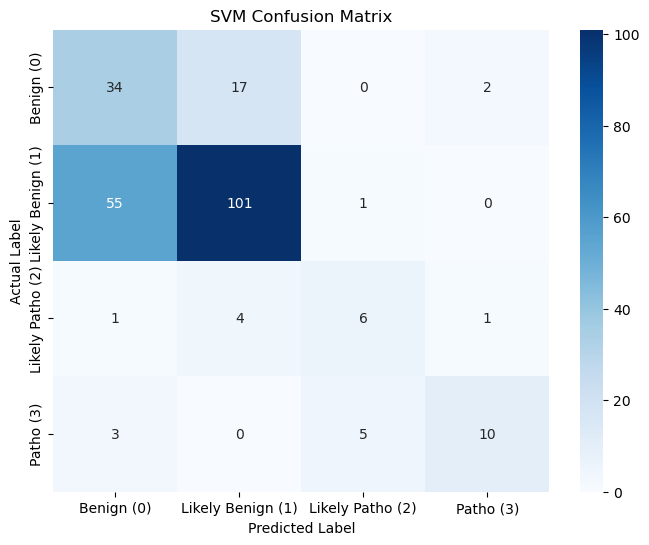

In [180]:
print(f"Overall Accuracy: {accuracy_score(y_data_test, predictions)}\n")
print("Balanced accuracy:", balanced_accuracy_score(y_data_test, predictions))
print(classification_report(y_data_test, predictions))
print("--- Classification Report ---")
print(classification_report(y_data_test, predictions))
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_data_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Benign (0)", "Likely Benign (1)", "Likely Patho (2)", "Patho (3)"],
            yticklabels=["Benign (0)", "Likely Benign (1)", "Likely Patho (2)", "Patho (3)"])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('SVM Confusion Matrix')
plt.show()

In [184]:
_label_map = {
    0: "benign",
    1: "likely_benign",
    2: "likely_pathogenic",
    3: "pathogenic",
}

unknown_pred_class = svm_pipeline.predict(unknown_model_data)
#gets the rows of the data that have the same index as the rows in the unknown_predictions_df
unknown_predictions_df = data.loc[unknown_model_data.index].copy()

unknown_predictions_df["svc_pred_class"] = unknown_pred_class
unknown_predictions_df["predicted_pathogenicity"] = unknown_predictions_df["svc_pred_class"].map(_label_map)

# Stores the original index of the data row as its own column in the unknown_predictions df so we can figure out which row maps to where
unknown_predictions_df["original_data_row_index"] = unknown_predictions_df.index


unknown_predictions_df["predicted_pathogenic"] = unknown_predictions_df["svc_pred_class"] == 3

unknown_predictions_df["predicted_pathogenic_spectrum"] = unknown_predictions_df["svc_pred_class"].isin([2, 3])

pathogenic_unknown = unknown_predictions_df[unknown_predictions_df["predicted_pathogenic"]].copy()
display(pathogenic_unknown)


,Gene_Symbol,rsID,Chromosome,Position,Ref_Allele,Alt_Allele,Variant_Type,Variant_Type_Label,Non_Coding_Region,Non_Coding_Region_Label,H3K4me3,H3K27ac,Top_TF_Binding,ClinVar_Significance,ClinVar_Significance_Label,GTEx_eQTL,Training_Split,H3K4me3_PeakCount,H3K4me3_PeakScore,H3K27ac_PeakScore,Sequence_Ref,Sequence_Alt,PhyloP_Score,Sequence_Status,TF_MNT_disrupted,TF_MNT_created,TF_MAX_disrupted,TF_MAX_created,TF_ELF1_disrupted,TF_CREB1_disrupted,TF_CREB1_created,TF_TOE1_created,TF_ELK1_disrupted,TF_ELK1_created,TF_OVOL1_created,TF_CLOCK_disrupted,TF_ZFX_disrupted,TF_ZFX_created,TF_FOS_disrupted,TF_FOS_created,TF_FOXA1_created,TF_MBD2_created,TF_JUND_disrupted,TF_CEBPG_created,TF_MSX2_disrupted,TF_MSX2_created,TF_MYC_disrupted,TF_GATA3_disrupted,TF_GATA3_created,TF_NR2F2_disrupted,TF_NR2F2_created,TF_E4F1_disrupted,TF_E4F1_created,TF_E2F8_disrupted,TF_E2F8_created,TF_FOXM1_disrupted,TF_FOXM1_created,TF_FOSL2_disrupted,TF_FOSL2_created,TF_Count_Disrupted,TF_Count_Created,Max_Disruption_Score,Most_Disrupted_TF,Most_Created_TF,Motif_Score_Reliable,svc_pred_class,predicted_pathogenicity,original_data_row_index,predicted_pathogenic,predicted_pathogenic_spectrum
11,BRCA1,rs80358348,Chr17,43047680,NaN,NaN,1,indel,7,nc_transcript,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,2,uncertain-significance,0,unlabeled,0,0.0,0.0,GCAGGCACCTTACCATGGAAGCCATTGTCCTCTGTCCAGGCATCTG...,GCAGGCACCTTACCATGGAAGCCATTGTCCTCTGTCCAGGCATCTG...,0.9764,no_refalt,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,0,3,pathogenic,11,True,True
16,BRCA1,rs55946644,Chr17,43049113,A,C,0,single nucleotide variant,2,intronic,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,2,not-provided,0,unlabeled,0,0.0,0.0,CTTGCTCACAGGAGAGAATATTGTGTCCTCCCTCTCTGACAGGGCA...,CTTGCTCACAGGAGAGAATATTGTGTCCTCCCTCTCTGACAGGGCA...,0.7581,ok,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,1,3,pathogenic,16,True,True
26,BRCA1,rs80358084,Chr17,43049202,G,A,0,single nucleotide variant,2,intronic,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,2,conflicting-interpretations-of-pathogenicity,0,unlabeled,0,0.0,0.0,ACCACAGAAGCACCACACAGCTGTACCATCCATTCCAGTTGATCTA...,ACCACAGAAGCACCACACAGCTGTACCATCCATTCCAGTTGATCTA...,0.5323,ok,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,1,3,pathogenic,26,True,True
41,BRCA1,rs397509251,Chr17,43057048,T,A,0,single nucleotide variant,2,intronic,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,2,uncertain-significance,0,unlabeled,0,0.0,0.0,GGAATACAGAGTGGTGGGGTGAGATTTTTGTCAACTTGAGGGAGGG...,GGAATACAGAGTGGTGGGGTGAGATTTTTGTCAACTTGAGGGAGGG...,2.5871,ok,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,1,3,pathogenic,41,True,True
42,BRCA1,rs397509250,Chr17,43057049,T,A,0,single nucleotide variant,2,intronic,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,2,conflicting-interpretations-of-pathogenicity,0,unlabeled,0,0.0,0.0,GAATACAGAGTGGTGGGGTGAGATTTTTGTCAACTTGAGGGAGGGA...,GAATACAGAGTGGTGGGGTGAGATTTTTGTCAACTTGAGGGAGGGA...,2.2414,ok,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,1,3,pathogenic,42,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1858,TP53,rs2543609319,Chr17,7675242,NaN,NaN,1,indel,1,5_prime_UTR,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,2,uncertain-significance,0,unlabeled,0,0.0,0.0,GGTCTTGGCCAGTTGGCAAAACATCTTGTTGAGGGCAGGGGAGTAC...,GGTCTTGGCCAGTTGGCAAAACATCTTGTTGAGGGCAGGGGAGTAC...,-0.0820,no_refalt,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,NaN,NaN,0,3,pathogenic,1858,True,True
1859,TP53,rs2543609378,Chr17,7675243,NaN,NaN,1,indel,1,5_prime_UTR,0,0,CTCF; POLR2A; H2AFZ; POLR2AphosphoS5; MAX,2,uncertain-significance,0,unl